In [ ]:
# Necessitites

!pip install missingno

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import missingno as msno


In [3]:
FILE_PATH = "/content/Dataset-SA.csv" # Provide the from which data will be imported

In [4]:
try:
  df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
  print(f' File not found at {FILE_PATH} bro!')

In [12]:
df.shape # A lot of rows !!!

(205052, 6)

In [24]:
df.info(memory_usage='deep') # The csv file is approx 100 MB (no problem for now , but for bigger datasets we may need a robust pipeline to load the data in pieces)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 93.6 MB


In [36]:
df.columns # 6 columns , and two review columns : review(short review) and summary.

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')

In [37]:
df.isna().sum() # There are some rows where the reviews are missing we may need to find out whether this pattern is specifiv for a certain product OR MAR.

,0
product_name,0
product_price,0
Rate,0
Review,24664
Summary,11
Sentiment,0


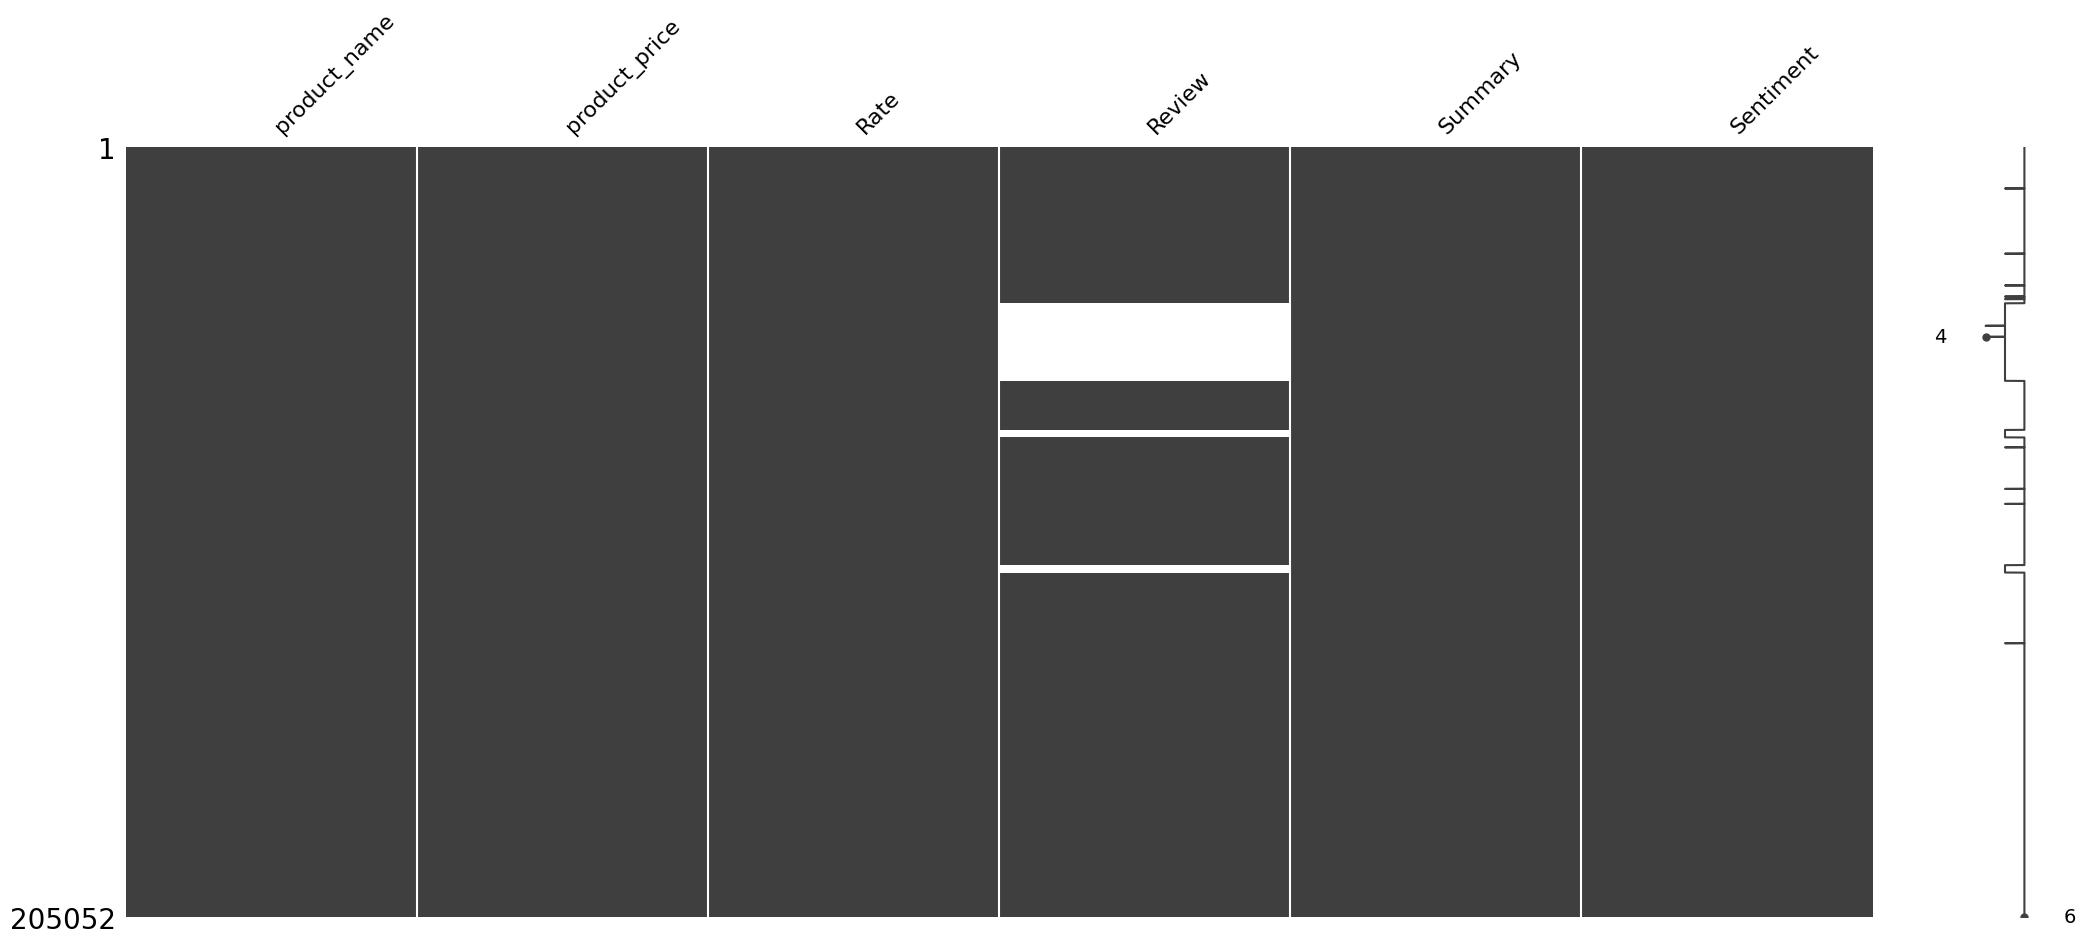

In [41]:
msno.matrix(df)
plt.show()

In [42]:
# The intution was right and the missing reviews are for some certain products only
# The number of summary rows missing is almost negligible comparing to the actual dataset size (So we can ignore it ).

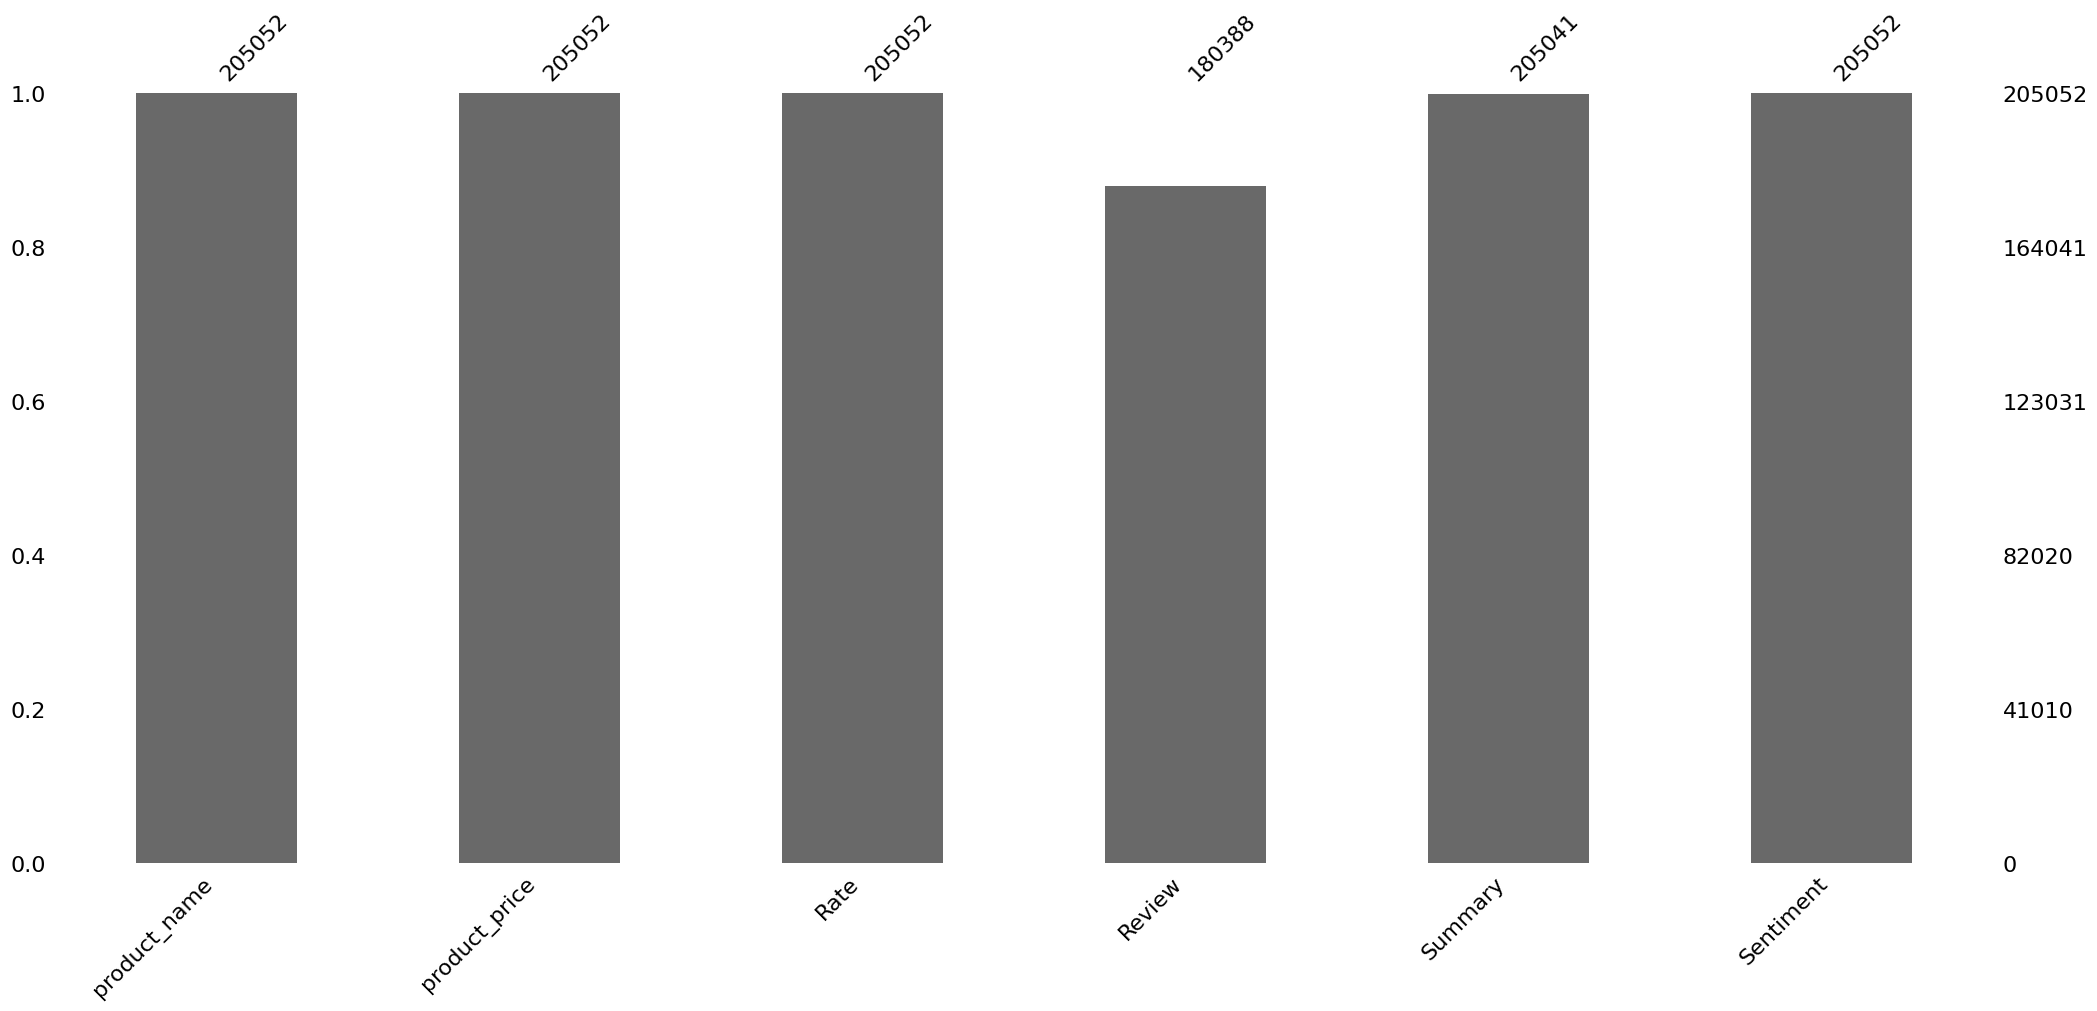

In [47]:
msno.bar(df)
plt.show()

In [50]:
df[df['Review'].isna()]

,product_name,product_price,Rate,Review,Summary,Sentiment
41625,Top - Pyjama Set Thermal For Boys & Girls?????...,365,5,NaN,best product,positive
41626,Top - Pyjama Set Thermal For Boys & Girls?????...,365,5,NaN,very good,positive
41627,Top - Pyjama Set Thermal For Boys & Girls?????...,365,5,NaN,very comfortablegood qualitylove it,positive
41628,Top - Pyjama Set Thermal For Boys & Girls?????...,365,5,NaN,very soft and comfortable go for it,positive
41629,Top - Pyjama Set Thermal For Boys & Girls?????...,365,5,NaN,super product quality is vry good tnx flipkart,positive
...,...,...,...,...,...,...
113340,Men 9325 Latest Collection Stylish Sports Snea...,299,3,NaN,ok oky hai according prise,positive
113341,Men 9325 Latest Collection Stylish Sports Snea...,299,5,NaN,nice,positive
113342,Men 9325 Latest Collection Stylish Sports Snea...,299,5,NaN,nice product,positive
113343,Men 9325 Latest Collection Stylish Sports Snea...,299,3,NaN,nice,positive


In [52]:
df[df['Review'].isna()]['product_name'].value_counts()[:10] # There are like 117 items with missing rows

,count
product_name,
Men Cargos,2000
Men Graphic Print Round Neck Black T-Shirt,1681
"Pack of 2 Solid Men Dark Grey, Grey Casual Shorts",1347
Boys Full Sleeve Solid Hooded Sweatshirt,1286
Printed Men Three Fourths,1118
VH000010A Analog Watch - For Women,1093
"Men 9325 Latest Collection Stylish Sports Sneakers Running Shoes Running Shoes For Men????(Red, Black)",999
Men LPMXT-800 Grey Clogs Sandal,931
Men Black Sandal,876


In [132]:
missing_reviews = pd.DataFrame({
    "product" : df[df['Review'].isna()]['product_name'].value_counts().index,
    "no_missing_reviews" : df[df['Review'].isna()]['product_name'].value_counts().values
})

In [133]:
missing_reviews

,product,no_missing_reviews
0,Men Cargos,2000
1,Men Graphic Print Round Neck Black T-Shirt,1681
2,"Pack of 2 Solid Men Dark Grey, Grey Casual Shorts",1347
3,Boys Full Sleeve Solid Hooded Sweatshirt,1286
4,Printed Men Three Fourths,1118
...,...,...
112,"Viscose Blend Solid, Self Design Beige Men Dup...",10
113,Men Checkered Double Breasted Formal Blazer???...,10
114,"Women Casual, Formal, Party, Evening Black, Go...",10
115,VH000008C Analog Watch - For Women,4


In [138]:
counts = df['product_name'].value_counts()

# Maps the values directly based on the product name text alignment
missing_reviews['no_reviews'] = missing_reviews['product'].map(counts)
missing_reviews['percentage_missing'] = (missing_reviews['no_missing_reviews'] / missing_reviews['no_reviews'])*100

In [142]:
missing_reviews.sort_values(by='percentage_missing').head()

,product,no_missing_reviews,no_reviews,percentage_missing
0,Men Cargos,2000,2000,100.0
1,Men Graphic Print Round Neck Black T-Shirt,1681,1681,100.0
2,"Pack of 2 Solid Men Dark Grey, Grey Casual Shorts",1347,1347,100.0
3,Boys Full Sleeve Solid Hooded Sweatshirt,1286,1286,100.0
4,Printed Men Three Fourths,1118,1118,100.0


In [141]:
missing_reviews.sort_values(by='percentage_missing').tail()

,product,no_missing_reviews,no_reviews,percentage_missing
112,"Viscose Blend Solid, Self Design Beige Men Dup...",10,10,100.0
113,Men Checkered Double Breasted Formal Blazer???...,10,10,100.0
114,"Women Casual, Formal, Party, Evening Black, Go...",10,10,100.0
115,VH000008C Analog Watch - For Women,4,4,100.0
116,VH000008D Analog Watch - For Women,4,4,100.0


In [143]:
# So this means the reviews for product which are missing are missing completely meaning there are no reviews for that product in the dataset completely.

In [71]:
# Calculate the percentage of missing reviews for each unique product
missing_by_product = df.groupby('product_name')['Review'].apply(lambda x: x.isna().mean() * 100)

# Sort to see the products with the highest rate of missing reviews
print("Percentage of missing reviews per product:")
print(missing_by_product.sort_values(ascending=False).head(10))


Percentage of missing reviews per product:
product_name
Women White Sling Bag                                                100.0
Women Relaxed Maroon Viscose Rayon Trousers                          100.0
Women Regular Fit White Viscose Rayon Trousers                       100.0
Women Regular Fit White Cotton Blend Trousers                        100.0
Women Regular Fit Red Viscose Rayon Trousers                         100.0
Women Regular Fit Cream Viscose Rayon Trousers                       100.0
Women Regular Fit Black Viscose Rayon Trousers                       100.0
Women Regular Fit Black Georgette Trousers                           100.0
Women Pink Hand-held Bag                                             100.0
Women Party, Evening, Formal, Party Black Artificial Leather Belt    100.0
Name: Review, dtype: float64


In [ ]:
# Most of the products missing are Women products .

In [5]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [74]:
df.tail()

,product_name,product_price,Rate,Review,Summary,Sentiment
205047,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,must buy!,good product,positive
205048,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,super!,nice,positive
205049,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,3,nice,very nice and fast delivery,positive
205050,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,just wow!,awesome product,positive
205051,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,4,value-for-money,very good but mixing bowl not included is one ...,neutral


In [77]:
df.sample(5)

,product_name,product_price,Rate,Review,Summary,Sentiment
693,MAHARAJA WHITELINE 65 L Desert Air Cooler?????...,7999,5,terrific,super,positive
59134,VH000010A Analog Watch - For Women,1169,4,NaN,good,positive
17658,"Pigeon Favourite Electric Kettle??????(1.5 L, ...",699,4,nice product,under budget price best,positive
140006,Baby Girls PartyFestive Dress SlingbagMulticolor,269,4,not specified,very good,positive
115507,Mi 5A 80 cm (32 inch) HD Ready LED Smart Andro...,13999,5,perfect product!,i saw a comment for prime not working i had sa...,positive


In [73]:
print(df.isna().corr()['Review']) # Okay so this basically says that every time any row is missing the 'Review' column is missing as well with other missing cols.

product_name          NaN
product_price         NaN
Rate                  NaN
Review           1.000000
Summary          0.001386
Sentiment             NaN
Name: Review, dtype: float64


In [34]:
# Initially this table looks a lot dirty because of the question marks and all present in the product_name , which may cause confusion.
# We need to handle this efficiently

In [35]:
# Also let us now decode a single row and the content it has

In [54]:
df.iloc[0,0] # This review is about a Air Cooler with specs also in the product_name

'Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)'

In [56]:
df.iloc[0,1:] # It has a price of 3999

,0
product_price,3999
Rate,5
Review,super!
Summary,great cooler excellent air flow and for this p...
Sentiment,positive


In [58]:
df.iloc[0,4]

'great cooler excellent air flow and for this price its so amazing and unbelievablejust love it'

In [ ]:
# The first reviewer has given :
"""
Rating  : 5 (Indicating a satisfactory product)
Review  : super! (Meaning he really liked it !)
Summary : great cooler excellent air flow and for this price its so amazing and unbelievablejust love it (Intenting he really liked it )
"""

# Sentiement predicted was positive for this and this is actually true.

In [7]:
df['product_name'].nunique() # There are a total of 958 unique products

958

In [62]:
df['product_name'].unique()[:15] # The names also have aspect for that product besides it .

array(['Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)',
       'Candes 60 L Room/Personal Air Cooler??????(White, Black, CRETA)',
       'MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)',
       'Crompton 75 L Desert Air Cooler??????(White, Teal, ACGC-DAC751)',
       'boAt Rockerz 510 Super Extra Bass Bluetooth Headset??????(Molten Orange, On the Ear)',
       'Aroma NB119 Titanium - 48 Hours Playtime Bluetooth Neckband Bluetooth Headset??????(Green, In the Ear)',
       'OnePlus Bullets Wireless Z2 with Fast Charge, 30 Hrs Battery Life, Earphones with mic Bluetooth Headset??????(Magico Black, In the Ear)',
       'OnePlus Bullets Wireless Z2 Bluetooth Headset??????(Acoustic Red, In the Ear)',
       'Mivi Roam2 5 W Bluetooth Speaker??????(Black, Mono Channel)',
       'etmax NANO BLACK 30 W Bluetooth Home Theatre??????(Black, Stereo Channel)',
       'Mivi Fort S16 Soundbar w

In [15]:
df['Sentiment'].value_counts() # Imbalanced classes

,count
Sentiment,
positive,166581
negative,28232
neutral,10239


In [18]:
df[((df['Rate'] == 5) & (df['Sentiment'] == 'negative'))]

,product_name,product_price,Rate,Review,Summary,Sentiment


In [19]:
df[((df['Rate'] == 1) & (df['Sentiment'] == 'positive'))]

,product_name,product_price,Rate,Review,Summary,Sentiment


In [63]:
# No fully wrong classified samples and no contradictorary class assigned

In [22]:
(df['Review'].str.len().describe())

,Review
count,180388.000000
mean,12.619659
std,4.985880
min,2.000000
25%,9.000000
50%,12.000000
75%,16.000000
max,140.000000
